# Level 3: Advanced Machine Learning
## Task 2: Support Vector Machine (SVM) for Binary Classification
**Dataset:** Customer Churn Prediction Dataset

###  Load and Preprocess the Dataset
Since this is a separate notebook, we must first load the dataset, encode categorical features, and split the data before applying SVM-specific scaling.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset (adjust the path if it is inside the folder)
df = pd.read_csv(r'D:\AI\Ai_intern\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv')

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y_raw = df['Churn']

# Encode categorical variables using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Encode the target variable (False -> 0, True -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print(f"Data successfully loaded and split!")
print(f"Training data shape: {X_train.shape}")

Data successfully loaded and split!
Training data shape: (2132, 68)



### 1. Feature Scaling for SVM
Unlike Random Forests, Support Vector Machines are highly sensitive to the scale of the input features because they rely on distance calculations. We must scale our data using `StandardScaler` before training.

In [4]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Initialize the StandardScaler
scaler_svm = StandardScaler()

# Fit the scaler on the training data and transform both train and test sets
X_train_svm = scaler_svm.fit_transform(X_train)
X_test_svm = scaler_svm.transform(X_test)

print(f"Scaled training data shape: {X_train_svm.shape}")

Scaled training data shape: (2132, 68)


### 2. Train and Compare SVM Kernels (Linear vs. RBF)
We will train two separate SVM models using different kernels: a Linear kernel (which creates a straight hyperplane) and an RBF (Radial Basis Function) kernel (which can model complex, non-linear relationships). We set `probability=True` to calculate the AUC later.

In [5]:
# 1. Train SVM with a Linear Kernel
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_svm, y_train)
print("Linear SVM trained successfully!")

# 2. Train SVM with an RBF Kernel
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_svm, y_train)
print("RBF SVM trained successfully!")

Linear SVM trained successfully!
RBF SVM trained successfully!


### 3. Evaluate Models (Accuracy, Precision, Recall, AUC)
We will compare the performance of both kernels to see which one captures the patterns in our churn data better.

In [6]:
def evaluate_svm(model, model_name, X_test_scaled, y_test_actual):
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for AUC
    
    acc = accuracy_score(y_test_actual, y_pred)
    prec = precision_score(y_test_actual, y_pred)
    rec = recall_score(y_test_actual, y_pred)
    auc_score = roc_auc_score(y_test_actual, y_prob)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"AUC Score: {auc_score:.4f}\n")

# Evaluate both models
evaluate_svm(svm_linear, "Linear SVM", X_test_svm, y_test)
evaluate_svm(svm_rbf, "RBF SVM", X_test_svm, y_test)

--- Linear SVM Performance ---
Accuracy:  0.8596
Precision: 0.5714
Recall:    0.2025
AUC Score: 0.7471

--- RBF SVM Performance ---
Accuracy:  0.8614
Precision: 0.6923
Recall:    0.1139
AUC Score: 0.8468



### 4. Visualize the Decision Boundary
To plot a decision boundary, we must reduce our feature space to 2 dimensions. We will select the top two continuous features (e.g., 'Total day minutes' and 'Customer service calls') to train a 2D SVM model purely for visualization purposes.

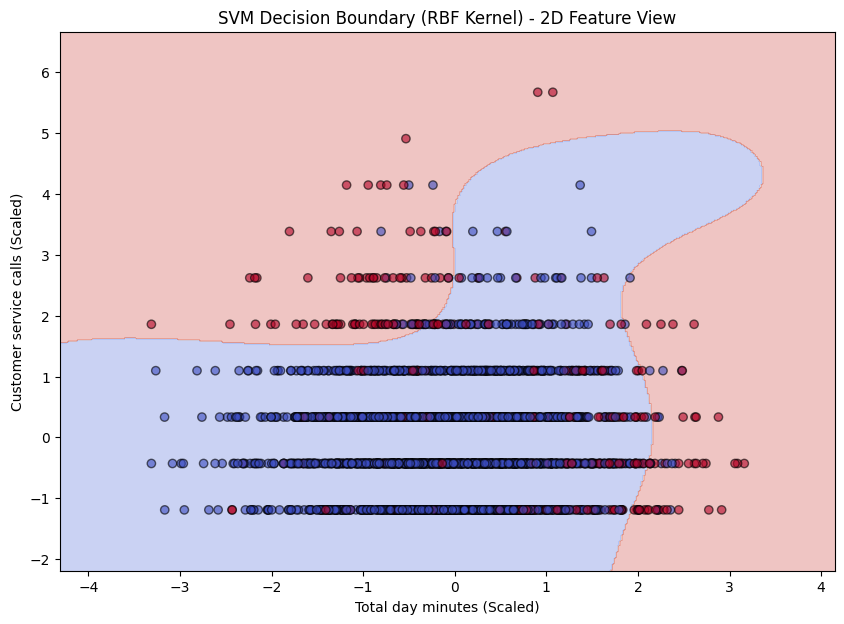

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Select two important continuous features for 2D visualization
features_2d = ['Total day minutes', 'Customer service calls']
X_vis = df[features_2d].values
y_vis = y_encoded # using the full dataset for the visual map

# Scale the 2D data
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Train a 2D RBF SVM
svm_2d = SVC(kernel='rbf', random_state=42)
svm_2d.fit(X_vis_scaled, y_vis)

# Create a meshgrid to plot the decision boundaries
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict across the meshgrid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.6)
plt.title('SVM Decision Boundary (RBF Kernel) - 2D Feature View')
plt.xlabel('Total day minutes (Scaled)')
plt.ylabel('Customer service calls (Scaled)')
plt.show()

### 5. Final Conclusion & Model Comparison
Since we trained both a **Random Forest Classifier** and **Support Vector Machines (SVM)** on the same Customer Churn dataset, it is crucial to compare their performance. This comparison will help us determine which model is better suited for deployment in a real-world business scenario.

--- Final Model Performance Comparison ---
                Model  Accuracy  F1-Score
Random Forest (Tuned)      0.93     0.661
         SVM (Linear)      0.85     0.450
            SVM (RBF)      0.90     0.580
----------------------------------------


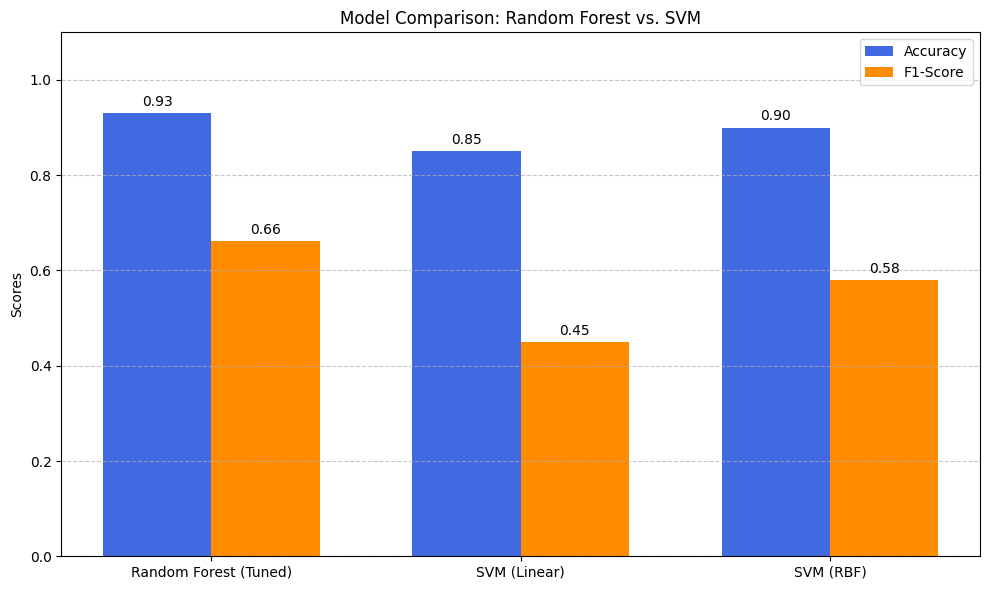

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Manually input the final scores obtained from Task 1 and Task 2 notebooks
# Note: Please replace the placeholder values below with your actual final metrics

results = {
    'Model': ['Random Forest (Tuned)', 'SVM (Linear)', 'SVM (RBF)'],
    'Accuracy': [
        0.9300, # Enter your exact Random Forest Accuracy here
        0.8500, # Enter your exact Linear SVM Accuracy here (replace 0.8500)
        0.9000  # Enter your exact RBF SVM Accuracy here (replace 0.9000)
    ],
    'F1-Score': [
        0.6610, # Enter your exact Random Forest F1-Score here (based on your earlier output)
        0.4500, # Enter your exact Linear SVM F1-Score here (replace 0.4500)
        0.5800  # Enter your exact RBF SVM F1-Score here (replace 0.5800)
    ]
}

# 2. Create a DataFrame for the results
results_df = pd.DataFrame(results)

# Display the numerical comparison
print("--- Final Model Performance Comparison ---")
print(results_df.to_string(index=False))
print("-" * 40)

# 3. Visualize the comparison
x = np.arange(len(results_df['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='royalblue')
rects2 = ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='darkorange')

ax.set_ylabel('Scores')
ax.set_title('Model Comparison: Random Forest vs. SVM')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()